In [117]:
%load_ext autoreload
%autoreload 2

import os, sys
import matplotlib.pyplot as plt

sys.path.insert(0, "src")

from pandas import DataFrame
from analytics.metrics.time import TimeMetrics
from spec.enums import MainTableColumns as Cols
from spec.spec_definition import PS2Versions
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from analytics.preprocessors.edwards import TimeStampToDateTimePreprocessor, ClassSubsetPreprocessor
from analytics.preprocessors.codebench import YAMLLinkURLPreprocessor, CodeBenchAddParentEventIDs
from analytics.preprocessors.codeworkout import CodeWorkoutExtractErrorTypesPreprocessor
from analytics.ps2_dataset import SortPreprocessor
from spec.enums import EventType

config_path = None
problem_id_col = None
timestamp_col = None
idle_gap = None
break_gap = None
proprocessing_steps = []
link_preprocessing_steps = []
submit_event = EventType.Submit
grades_link_table = "Subject"
grades_col = None
start_time = None
end_time = None
early_percentage = None
assignment_ids = None
compile_error_type_col = Cols.CompileMessageType
compile_event = EventType.Compile
compile_error_event = EventType.CompileError
output_suffix = ''

# Note: Only Fall has compilation data; spring has no Run.Program events!
edwards_s19_config = {
    "config_path": "sample_data_configs/edwards2019.yaml",
    "problem_id_col": Cols.AssignmentID,
    "timestamp_col": Cols.ClientTimestamp,
    "idle_gap": 30,
    "break_gap": 3 * 60,
    "proprocessing_steps": [
        # Don't need this, since I've done and cached it
        # AddErrors2021Preprocessor(),
        TimeStampToDateTimePreprocessor(),
        # Make sure this comes last so Fall is correct
        ClassSubsetPreprocessor("Spring"),
    ],
    # Compile error info is stored in the Run.Program event itself
    "compile_event": EventType.RunProgram,
    "end_time": "2019-02-25 00:00:00",
    "early_percentage": 0.23,
    "assignment_ids": ["p4s", "p5s"],  # Only 2 assignments
    "grades_col": "exam2",
    "output_suffix": "-s19",
}

edwards_f19_config = edwards_s19_config.copy()
edwards_f19_config["proprocessing_steps"] = edwards_s19_config["proprocessing_steps"].copy()
edwards_f19_config["proprocessing_steps"][-1] = ClassSubsetPreprocessor("Fall")
edwards_f19_config["end_time"] = "2019-10-13 00:00:00"
edwards_f19_config["assignment_ids"] = ["p4f", "p5f"]
edwards_f19_config["early_percentage"] = 0.42
edwards_f19_config["output_suffix"] = "-f19"

edwards2021_config = {
    "config_path": "sample_data_configs/edwards2021.yaml",
    "problem_id_col": Cols.AssignmentID,
    "timestamp_col": Cols.ClientTimestamp,
    "idle_gap": 30,
    "break_gap": 3 * 60,
    "proprocessing_steps": [
        # Don't need this, since I've done and cached it
        # AddErrors2021Preprocessor(),
        TimeStampToDateTimePreprocessor(),
    ],
    # Compile error info is stored in the Run.Program event itself
    "compile_event": EventType.RunProgram,
    "end_time": "2022-01-01 00:00:00",
    "early_percentage": 0.4,
    "assignment_ids": ["Assign6", "Assign7"],  # Only 2 assignments
    "grades_col": "FinalScore",
}

cwo_s19_config = {
    "config_path": "sample_data_configs/cwo_s19.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 5 * 60,
    "break_gap": 30 * 60,
    "proprocessing_steps": [
        SortPreprocessor(),
        CodeWorkoutExtractErrorTypesPreprocessor(),
    ],
    "submit_event": EventType.RunProgram,
    "grades_col": "X-Grade",
    "early_percentage": 0.33,
}

cwo_f19_config = {
    "config_path": "sample_data_configs/cwo_f19.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 5 * 60,
    "break_gap": 30 * 60,
    "proprocessing_steps": [
        SortPreprocessor(),
        CodeWorkoutExtractErrorTypesPreprocessor(),
    ],
    "submit_event": EventType.RunProgram,
    "grades_col": "X-Grade",
    "early_percentage": 0.25,
}

codebench2024_config = {
    "config_path": "sample_data_configs/codebench2024.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 30,
    "break_gap": 3 * 60,
    "link_preprocessing_steps": [YAMLLinkURLPreprocessor(True)],
    "main_table_preprocessing_steps": [
        CodeBenchAddParentEventIDs(),
    ],
    "grades_link_table": "CourseSubject",
    "grades_col": "final-grade",
    "start_time": "2024-09-01 00:00:00",
    "early_percentage": 0.28,
    "compile_error_type_col": "ProgramErrorOutput",
    "compile_event": EventType.Submit,
    "compile_error_event": EventType.RunTest,
}

# config = cwo_f19_config
# config = cwo_s19_config
# config = codebench2024_config
# config = edwards2021_config
# config = edwards_s19_config
config = edwards_f19_config
locals().update(config)

In [129]:
from database.config import PS2DataConfig

spec = PS2Versions.v1_0.load()

data_config = PS2DataConfig.from_yaml(config_path, spec)


In [130]:
from analytics.ps2_dataset import PS2Dataset

dataset = PS2Dataset(spec, data_config)
for i, step in enumerate(proprocessing_steps):
    dataset.main_table_preprocessors.insert(i, step)
for i, step in enumerate(link_preprocessing_steps):
    dataset.link_table_preprocessors.insert(i, step)

In [131]:
main_table = dataset.get_main_table()
main_table.head()

c:\Users\twprice\Documents\GitHub\ProgSnap2\src\database\reader\csv_reader.py:20: DtypeWarning: Columns (0,12,13,14,15,19) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


,EventID,SubjectID,AssignmentID,CodeStateSection,X-Task,EventType,X-Keystroke,InsertText,DeleteText,SourceLocation,...,X-RunOutput,X-RunHasError,X-RunUserTerminated,X-RawAssignmentID,X-Term,X-Compilable,CompileMessageType,ParentEventID,Score,X-ClassID
4673167,8410070,S479,p4s,task1.py,1,X-SwitchTask,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,p4,s,1,NaN,NaN,NaN,Spring
4673168,8410071,S479,p4s,task1.py,1,File.Edit,NaN,# Don't forget comments that go here\n\n\n,NaN,0.0,...,NaN,NaN,NaN,p4,s,1,NaN,NaN,NaN,Spring
4673169,8410072,S479,p4s,task0.py,0,X-SwitchTask,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,p4,s,1,NaN,NaN,NaN,Spring
4673170,8410073,S479,p4s,task0.py,0,File.Edit,NaN,# Don't forget comments that go here\n,NaN,0.0,...,NaN,NaN,NaN,p4,s,1,NaN,NaN,NaN,Spring
4673171,8410074,S479,p4s,task0.py,0,File.Edit,i,i,NaN,37.0,...,NaN,NaN,NaN,p4,s,1,NaN,NaN,NaN,Spring


In [132]:
main_table[problem_id_col].unique()

array(['p4s', 'p5s', 'p6s', 'p7s', 'p8s'], dtype=object)

In [133]:
bad_assignment_ids = [407610653, 1147927607, 1407437764]
main_table = main_table[~main_table[Cols.AssignmentID].isin(bad_assignment_ids)]

In [134]:
if start_time is not None:
    main_table = main_table[main_table[timestamp_col] >= start_time]
if end_time is not None:
    main_table = main_table[main_table[timestamp_col] <= end_time]

In [135]:
if "X-ClassID" in main_table.columns:
    class_counts = main_table["X-ClassID"].value_counts()
    print(class_counts)
    min_count = 1000
    invalid_class_ids = class_counts[class_counts < min_count].index
    print(f"Removing classes with less than {min_count} submissions: {invalid_class_ids}")
    main_table = main_table[~main_table["X-ClassID"].isin(invalid_class_ids) & ~main_table["X-ClassID"].isna()]

X-ClassID
Spring    2311309
Name: count, dtype: int64
Removing classes with less than 1000 submissions: Index([], dtype='object', name='X-ClassID')


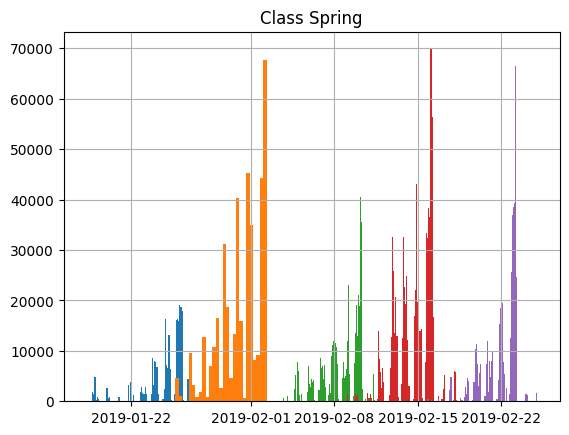

In [136]:
if "X-ClassID" not in main_table.columns:
    main_table.groupby(Cols.AssignmentID)[timestamp_col].hist(bins=100)
else:
    classes = main_table["X-ClassID"].unique()
    classes = classes[~pd.isna(classes)]
    for class_id in classes:
        subset = main_table[main_table["X-ClassID"] == class_id]
        hist = subset.groupby(Cols.AssignmentID)[timestamp_col].hist(bins=100)
        plt.title(f"Class {class_id}")
        plt.show()

In [137]:
import numpy as np
for i in main_table[timestamp_col].quantile(np.arange(0, 1.01, 0.01)).to_list():
    print(i)

2019-01-18 04:53:11.918000128+00:00
2019-01-22 03:19:45.647399936+00:00
2019-01-23 20:55:21.064000+00:00
2019-01-24 03:31:28.252519936+00:00
2019-01-24 21:42:24.185080064+00:00
2019-01-25 04:07:32.890200064+00:00
2019-01-25 18:04:00.768560128+00:00
2019-01-25 21:26:36.394400+00:00
2019-01-26 00:32:20.474759936+00:00
2019-01-26 03:46:59.189519872+00:00
2019-01-26 06:22:31.027000064+00:00
2019-01-27 08:01:45.146080256+00:00
2019-01-28 17:15:38.186599936+00:00
2019-01-29 06:01:36.950759936+00:00
2019-01-29 20:26:25.614120192+00:00
2019-01-30 00:09:57.882800128+00:00
2019-01-30 16:39:11.358919936+00:00
2019-01-30 21:28:16.518799872+00:00
2019-01-31 00:46:38.594319872+00:00
2019-01-31 16:13:22.915120128+00:00
2019-01-31 20:47:18.392000+00:00
2019-01-31 22:56:14.859000064+00:00
2019-02-01 03:41:12.825560064+00:00
2019-02-01 17:57:22.139760128+00:00
2019-02-01 22:12:21.331919872+00:00
2019-02-02 01:11:49.128000+00:00
2019-02-02 03:25:31.922159872+00:00
2019-02-02 05:03:52.031000064+00:00
2019

In [138]:
#get the data of the third quantile
max = main_table[timestamp_col].max()
min = main_table[timestamp_col].min()
range = max - min
time_cutoff = min + range * early_percentage
print(time_cutoff)
print(main_table[timestamp_col].min())
print(main_table[timestamp_col].max())

data_subset = main_table[main_table[timestamp_col] <= time_cutoff]
print("Assignment IDs:", data_subset[Cols.AssignmentID].unique())
if Cols.ProblemID in data_subset.columns:
    print("Problem IDs:", data_subset[Cols.ProblemID].unique())
print("Total number of rows:", len(data_subset))
print("Percent of logs: ", len(data_subset) / len(main_table) * 100)
print("Percent of assignments: ", len(data_subset[Cols.AssignmentID].unique()) / len(main_table[Cols.AssignmentID].unique()) * 100)
if Cols.ProblemID in main_table.columns:
    print("Percent of problems: ", len(data_subset[Cols.ProblemID].unique()) / len(main_table[Cols.ProblemID].unique()) * 100)
# Assignment IDs: [597 600]
# Problem IDs: [13 232 235 234 236   5 233   1   3  12  24 100 101  25 102  28  21  20  17  22]

2019-01-26 21:31:20.754740+00:00
2019-01-18 04:53:11.918000+00:00
2019-02-24 23:59:55.556000+00:00
Assignment IDs: ['p4s' 'p5s']
Total number of rows: 245346
Percent of logs:  10.615023780896452
Percent of assignments:  40.0


In [139]:
if assignment_ids is not None:
    data_subset = data_subset[data_subset[Cols.AssignmentID].isin(assignment_ids)]

In [140]:
testing_student_subset = data_subset[Cols.SubjectID].unique()[:50]
testing_mt_subset = data_subset[data_subset[Cols.SubjectID].isin(testing_student_subset)]

In [141]:
grouping_cols = ["X-ClassID", Cols.SubjectID, problem_id_col]
grouping_cols = [col for col in grouping_cols if col in main_table.columns]

In [142]:
# TODO: Edwards 2019 Spring is missing compile error types...
main_table[compile_error_type_col].value_counts()

Series([], Name: count, dtype: int64)

In [143]:
from analytics.metrics.errors import ErrorMetrics


error_metrics = ErrorMetrics(True,
                             compile_message_type_column=compile_error_type_col,
                             compile_event=compile_event,
                             compile_error_event=compile_error_event)

error_results = data_subset.groupby(grouping_cols).apply(error_metrics.calculate)
error_results.head()

C:\Users\twprice\AppData\Local\Temp\ipykernel_3732\4122987523.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  error_results = data_subset.groupby(grouping_cols).apply(error_metrics.calculate)


ErrorQuotient  RepeatedErrorDensity  \
X-ClassID SubjectID AssignmentID                                        
Spring    S001      p4s                     0.0                   0.0   
          S006      p4s                     0.0                   0.0   
          S007      p4s                     0.0                   0.0   
          S008      p4s                     0.0                   0.0   
          S009      p4s                     0.0                   0.0   

                                  FailedCompileCount  
X-ClassID SubjectID AssignmentID                      
Spring    S001      p4s                          0.0  
          S006      p4s                          0.0  
          S007      p4s                          0.0  
          S008      p4s                          0.0  
          S009      p4s                          0.0

In [144]:
# Investigating a single Edwards 2021 student to see why EQ/RED are so low
# Errors tend not to be repeated and there are many successful runs
# data_subset[
#     (data_subset[Cols.SubjectID] == "Student1") &
#     (data_subset[Cols.AssignmentID] == "Assign7") &
#     ((data_subset[Cols.EventType] == EventType.CompileError) | (data_subset[Cols.EventType] == EventType.RunProgram))
# ].head(40)

In [145]:
# EQ is very low for codebench because most runs have no errors
# It's interesting/odd that EQ and RED don't correlate on this dataset

error_results.describe()

,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
count,170.0,170.0,175.0
mean,0.0,0.0,0.0
std,0.0,0.0,0.0
min,0.0,0.0,0.0
25%,0.0,0.0,0.0
50%,0.0,0.0,0.0
75%,0.0,0.0,0.0
max,0.0,0.0,0.0


In [146]:
error_results.corr(method="spearman")

,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
ErrorQuotient,NaN,NaN,NaN
RepeatedErrorDensity,NaN,NaN,NaN
FailedCompileCount,NaN,NaN,NaN


<Axes: ylabel='Frequency'>

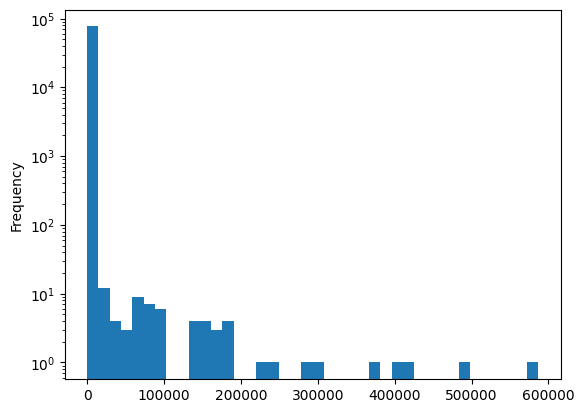

In [147]:
from analytics.metrics.time import TimeMetrics


diffs = TimeMetrics.get_all_diffs(testing_mt_subset, timestamp_col, grouping_cols)
diffs.DeltaSeconds[diffs.DeltaSeconds > 0].plot.hist(bins=40, log=True)

In [148]:
TimeMetrics.get_positive_diff_quantiles(data_subset, timestamp_col, grouping_cols) / 60

# Seems like 5 minutes (90th+ percentile) is a good cutoff for time spent on a problem between submissions
# 30m does seem to suggest that the student is not working on the problem

0.00       0.000017
0.25       0.002150
0.50       0.003517
0.75       0.011283
0.80       0.015083
0.85       0.021967
0.90       0.036233
0.95       0.088017
0.96       0.121083
0.97       0.180699
0.98       0.302459
0.99       0.637069
1.00    9776.621900
Name: DeltaSeconds, dtype: float64

In [149]:
from analytics.metrics.time import TimeMetrics

time_metrics = TimeMetrics(idle_gap, break_gap, True, timestamp_col)

result = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))
result

C:\Users\twprice\AppData\Local\Temp\ipykernel_3732\3223447471.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))


ActiveTime  PassiveTime  TotalTime  \
X-ClassID SubjectID AssignmentID                                       
Spring    S001      p4s               99.328      243.951    343.279   
          S006      p4s             1043.999     1112.034   2156.033   
          S007      p4s               17.386      104.839    122.225   
          S008      p4s               75.304       40.195    115.499   
          S009      p4s              751.435      266.582   1018.017   
...                                      ...          ...        ...   
          S497      p4s             4173.538     1513.586   5687.124   
          S501      p4s             4923.914     3197.037   8120.951   
          S506      p4s               81.203       70.405    151.608   
          S511      p4s             1289.884      693.620   1983.504   
          S516      p4s              137.205      176.091    313.296   

                                  ActiveTimeAfterCorrect  #Breaks  \
X-ClassID SubjectID AssignmentID                                    
Spring    S001      p4s                            0.000        1   
          S006      p4s                           18.527        1   
          S007      p4s                           26.030        0   
          S008      p4s                            0.000        1   
          S009      p4s                            0.000        0   
...                                                  ...      ...   
          S497      p4s                            0.000        6   
          S501      p4s                            0.000       11   
          S506      p4s                            0.000        0   
          S511      p4s                            0.000        3   
          S516      p4s                            0.000        1   

                                                        StartTime  \
X-ClassID SubjectID AssignmentID                                    
Spring    S001      p4s          2019-01-25 19:26:44.182000+00:00   
          S006      p4s          2019-01-24 00:26:58.549000+00:00   
          S007      p4s          2019-01-24 05:00:46.486000+00:00   
          S008      p4s          2019-01-18 17:09:07.644000+00:00   
          S009      p4s          2019-01-25 20:00:06.726000+00:00   
...                                                           ...   
          S497      p4s          2019-01-23 17:39:38.305000+00:00   
          S501      p4s          2019-01-24 22:38:51.908000+00:00   
          S506      p4s          2019-01-25 17:30:21.775000+00:00   
          S511      p4s          2019-01-24 21:14:21.967000+00:00   
          S516      p4s          2019-01-25 23:11:04.366000+00:00   

                                                 FirstCorrectTime  \
X-ClassID SubjectID AssignmentID                                    
Spring    S001      p4s          2019-01-25 20:12:38.546000+00:00   
          S006      p4s          2019-01-24 01:26:24.323000+00:00   
          S007      p4s          2019-01-24 05:02:48.711000+00:00   
          S008      p4s                                       NaT   
          S009      p4s          2019-01-25 20:17:04.743000+00:00   
...                                                           ...   
          S497      p4s          2019-01-24 00:30:46.202000+00:00   
          S501      p4s          2019-01-26 00:02:31.190000+00:00   
          S506      p4s          2019-01-25 17:32:53.383000+00:00   
          S511      p4s          2019-01-25 04:55:45.113000+00:00   
          S516      p4s                                       NaT   

                                                          EndTime  
X-ClassID SubjectID AssignmentID                                   
Spring    S001      p4s          2019-01-25 20:12:38.546000+00:00  
          S006      p4s          2019-01-24 01:40:48.992000+00:00  
          S007      p4s          2019-01-24 17:19:33.429000+00:00  
          S008      p4s          2019-01-18 17:52:55.775000+00:

In [150]:
result.describe()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks
count,175.000000,175.000000,175.000000,175.000000,175.000000
mean,1334.684291,895.741349,2230.425640,8.006246,3.331429
std,1461.320025,1046.782070,2430.824392,32.003857,4.482903
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,354.698000,217.977500,618.689000,0.000000,1.000000
50%,871.829000,539.745000,1387.998000,0.000000,2.000000
75%,1683.653500,1157.715500,2908.531000,0.580500,4.000000
max,7242.520000,7364.199000,14606.719000,378.489000,28.000000


In [151]:
from analytics.metrics.score import SubmissionScoreMetrics
from spec.enums import EventType

score_metrics = SubmissionScoreMetrics(submit_event)

subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


C:\Users\twprice\AppData\Local\Temp\ipykernel_3732\1178317524.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


In [152]:
subject_problem_score.head()

Attempts  FirstCorrect  EverCorrect  \
X-ClassID SubjectID AssignmentID                                        
Spring    S001      p4s                  1          True         True   
          S006      p4s                  1          True         True   
          S007      p4s                  1          True         True   
          S008      p4s                  0         False        False   
          S009      p4s                  1          True         True   

                                  Attempted  MaxScore  MinScore  MeanScore  \
X-ClassID SubjectID AssignmentID                                             
Spring    S001      p4s                True     100.0     100.0      100.0   
          S006      p4s                True     100.0     100.0      100.0   
          S007      p4s                True      95.0      95.0       95.0   
          S008      p4s               False       0.0       0.0        0.0   
          S009      p4s                True     100.0     100.0      100.0   

                                  TotalAttempts  
X-ClassID SubjectID AssignmentID                 
Spring    S001      p4s                       1  
          S006      p4s                       1  
          S007      p4s                       1  
          S008      p4s                       0  
          S009      p4s                       1

In [153]:
subject_problem_score.describe()

,Attempts,MaxScore,MinScore,MeanScore,TotalAttempts
count,175.000000,162.000000,162.000000,162.000000,175.000000
mean,1.902857,82.675926,82.675926,82.675926,1.902857
std,1.796146,36.617736,36.617736,36.617736,1.796146
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,95.000000,95.000000,95.000000,1.000000
50%,1.000000,100.000000,100.000000,100.000000,1.000000
75%,2.000000,100.000000,100.000000,100.000000,2.000000
max,11.000000,100.000000,100.000000,100.000000,11.000000


In [154]:
all_features = pd.merge(
    result.reset_index(),
    subject_problem_score.reset_index(),
    on=grouping_cols,
    how="outer"
)
all_features = pd.merge(
    all_features,
    error_results.reset_index(),
    on=grouping_cols,
    how="outer"
)
all_features.head()

,X-ClassID,SubjectID,AssignmentID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,...,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
0,Spring,S001,p4s,99.328,243.951,343.279,0.000,1,2019-01-25 19:26:44.182000+00:00,2019-01-25 20:12:38.546000+00:00,...,True,True,True,100.0,100.0,100.0,1,0.0,0.0,0.0
1,Spring,S006,p4s,1043.999,1112.034,2156.033,18.527,1,2019-01-24 00:26:58.549000+00:00,2019-01-24 01:26:24.323000+00:00,...,True,True,True,100.0,100.0,100.0,1,0.0,0.0,0.0
2,Spring,S007,p4s,17.386,104.839,122.225,26.030,0,2019-01-24 05:00:46.486000+00:00,2019-01-24 05:02:48.711000+00:00,...,True,True,True,95.0,95.0,95.0,1,0.0,0.0,0.0
3,Spring,S008,p4s,75.304,40.195,115.499,0.000,1,2019-01-18 17:09:07.644000+00:00,NaT,...,False,False,False,0.0,0.0,0.0,0,0.0,0.0,0.0
4,Spring,S009,p4s,751.435,266.582,1018.017,0.000,0,2019-01-25 20:00:06.726000+00:00,2019-01-25 20:17:04.743000+00:00,...,True,True,True,100.0,100.0,100.0,1,0.0,0.0,0.0


In [155]:
all_features.isna().mean()

X-ClassID                 0.000000
SubjectID                 0.000000
AssignmentID              0.000000
ActiveTime                0.000000
PassiveTime               0.000000
TotalTime                 0.000000
ActiveTimeAfterCorrect    0.000000
#Breaks                   0.000000
StartTime                 0.000000
FirstCorrectTime          0.222857
EndTime                   0.000000
Attempts                  0.000000
FirstCorrect              0.000000
EverCorrect               0.000000
Attempted                 0.000000
MaxScore                  0.074286
MinScore                  0.074286
MeanScore                 0.074286
TotalAttempts             0.000000
ErrorQuotient             0.028571
RepeatedErrorDensity      0.028571
FailedCompileCount        0.000000
dtype: float64

In [156]:
median_features = all_features.groupby(problem_id_col)[[TimeMetrics.ACTIVE_TIME, SubmissionScoreMetrics.MAX_SCORE]].median()
all_features_with_median = all_features.merge(
    median_features,
    on=problem_id_col,
    suffixes=("", "_median"),
    how="left"
)
all_features["AtLeatMedianActiveTime"] = (all_features[TimeMetrics.ACTIVE_TIME] >= all_features_with_median[TimeMetrics.ACTIVE_TIME + "_median"]) + 0
all_features["AtLeatMedianMaxScore"] = (all_features[SubmissionScoreMetrics.MAX_SCORE] >= all_features_with_median[SubmissionScoreMetrics.MAX_SCORE + "_median"]) + 0
all_features["HadEffort"] = all_features["AtLeatMedianActiveTime"] | all_features["AtLeatMedianMaxScore"]
all_features.describe()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,Attempts,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
count,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,162.000000,162.000000,162.000000,175.000000,170.0,170.0,175.0,175.000000,175.000000,175.000000
mean,1334.684291,895.741349,2230.425640,8.006246,3.331429,1.902857,82.675926,82.675926,82.675926,1.902857,0.0,0.0,0.0,0.502857,0.668571,0.828571
std,1461.320025,1046.782070,2430.824392,32.003857,4.482903,1.796146,36.617736,36.617736,36.617736,1.796146,0.0,0.0,0.0,0.501427,0.472077,0.377964
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
25%,354.698000,217.977500,618.689000,0.000000,1.000000,1.000000,95.000000,95.000000,95.000000,1.000000,0.0,0.0,0.0,0.000000,0.000000,1.000000
50%,871.829000,539.745000,1387.998000,0.000000,2.000000,1.000000,100.000000,100.000000,100.000000,1.000000,0.0,0.0,0.0,1.000000,1.000000,1.000000
75%,1683.653500,1157.715500,2908.531000,0.580500,4.000000,2.000000,100.000000,100.000000,100.000000,2.000000,0.0,0.0,0.0,1.000000,1.000000,1.000000
max,7242.520000,7364.199000,14606.719000,378.489000,28.000000,11.000000,100.000000,100.000000,100.000000,11.000000,0.0,0.0,0.0,1.000000,1.000000,1.000000


In [157]:
all_features_z = all_features.copy()

time_cols = [
    TimeMetrics.START_TIME,
    TimeMetrics.FIRST_CORRECT_TIME,
    TimeMetrics.END_TIME,
]

all_features_z[time_cols] = all_features_z[time_cols].astype('int64') / 1e9
numeric_cols = all_features_z.select_dtypes(include=["number"]).columns
# remove the grouping columns from numeric_cols
numeric_cols = numeric_cols.difference(grouping_cols)
all_features_z[numeric_cols] = all_features_z.groupby(problem_id_col)[numeric_cols].transform(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1))


In [158]:
all_features_z.head()

,X-ClassID,SubjectID,AssignmentID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,...,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
0,Spring,S001,p4s,-0.859942,-0.635443,-0.789929,-0.258082,-0.536111,0.753988,0.479530,...,0.433952,0.433952,0.433952,-0.531161,0.0,0.0,0.0,-1.003026,0.704961,0.460373
1,Spring,S006,p4s,-0.222452,0.179719,-0.055978,0.305011,-0.536111,-0.229806,0.479494,...,0.433952,0.433952,0.433952,-0.531161,0.0,0.0,0.0,0.990941,0.704961,0.460373
2,Spring,S007,p4s,-0.915239,-0.766074,-0.879430,0.533050,-0.755067,-0.125393,0.479497,...,0.287825,0.287825,0.287825,-0.531161,0.0,0.0,0.0,-1.003026,-1.409922,-2.158989
3,Spring,S008,p4s,-0.876154,-0.826777,-0.882153,-0.258082,-0.536111,-3.142505,-2.072772,...,-2.488604,-2.488604,-2.488604,-1.082365,0.0,0.0,0.0,-1.003026,-1.409922,-2.158989
4,Spring,S009,p4s,-0.419882,-0.614192,-0.516740,-0.258082,-0.755067,0.766715,0.479530,...,0.433952,0.433952,0.433952,-0.531161,0.0,0.0,0.0,-1.003026,0.704961,0.460373


In [159]:
all_features_z.RepeatedErrorDensity.isna().mean()

np.float64(0.02857142857142857)

In [160]:
all_na_eq = all_features.groupby(Cols.SubjectID).ErrorQuotient.apply(lambda x: pd.isna(x).all())
all_na_eq = all_na_eq[all_na_eq]
all_na_eq

SubjectID
S039    True
S091    True
S145    True
S234    True
Name: ErrorQuotient, dtype: bool

In [161]:
# In CWO, this student attempted all of 1 problem, got and error and gave up
# I think assigning a 1 makes more sense than a 0... but 0 is more generic and
# it's rare enough I'm not going to worry about it right now
data_subset[data_subset[Cols.SubjectID].isin(all_na_eq.index)]

,EventID,SubjectID,AssignmentID,CodeStateSection,X-Task,EventType,X-Keystroke,InsertText,DeleteText,SourceLocation,...,X-RunOutput,X-RunHasError,X-RunUserTerminated,X-RawAssignmentID,X-Term,X-Compilable,CompileMessageType,ParentEventID,Score,X-ClassID
1454095,2464979,S145,p4s,task1.py,1,File.Edit,NaN,# Don't forget comments that go here,NaN,0.0,...,NaN,NaN,NaN,p4,s,1,NaN,NaN,NaN,Spring
1454096,2464980,S145,p4s,task1.py,1,File.Edit,#,#,# Don't forget comments that go here,0.0,...,NaN,NaN,NaN,p4,s,1,NaN,NaN,NaN,Spring
1454097,2464981,S145,p4s,task1.py,1,File.Edit,j,j,NaN,1.0,...,NaN,NaN,NaN,p4,s,1,NaN,NaN,NaN,Spring
1454098,2464982,S145,p4s,task1.py,1,File.Edit,o,o,NaN,2.0,...,NaN,NaN,NaN,p4,s,1,NaN,NaN,NaN,Spring
1454099,2464983,S145,p4s,task1.py,1,File.Edit,s,s,NaN,3.0,...,NaN,NaN,NaN,p4,s,1,NaN,NaN,NaN,Spring
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445107,630787,S039,p5s,task1.py,1,File.Edit,NaN,# Task 2,NaN,0.0,...,NaN,NaN,NaN,p5,s,1,NaN,NaN,NaN,Spring
908709,1537341,S091,p4s,task1.py,1,File.Edit,NaN,# Don't forget comments that go here\n\n\n,NaN,0.0,...,NaN,NaN,NaN,p4,s,1,NaN,NaN,NaN,Spring
908710,1537342,S091,p4s,task0.py,0,X-SwitchTask,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,p4,s,1,NaN,NaN,NaN,Spring
908711,1537343,S091,p4s,task0.py,0,File.Edit,NaN,#@@@@@@@@@@@@@@\n#CS1400-1\n#Assn3\n\n#Use Tur...,NaN,0.0,...,NaN,NaN,NaN,p4,s,1,NaN,NaN,NaN,Spring


In [162]:
merge_cols = grouping_cols.copy()
merge_cols.remove(problem_id_col)
merge_cols = [col for col in merge_cols if col in all_features_z.columns]

subject_means = all_features_z.drop(problem_id_col, axis=1).groupby(merge_cols).mean()
# In theory this can happen is someone only has NA for all problems
# This apparently happened with EQ in CWO...

# For EQ, having no attempts with compile errors should give you
# the max value (whatever 1 is after normalization)
for col in [ErrorMetrics.ERROR_QUOTIENT]:
    max_val = subject_means[col].max()
    subject_means.iloc[:, subject_means.columns.get_loc(col)] = subject_means[col].fillna(max_val)

# But for RED it should be the minimum value (normalized 0)
for col in [ErrorMetrics.REPEATED_ERROR_DENSITY, SubmissionScoreMetrics.MAX_SCORE, SubmissionScoreMetrics.MEAN_SCORE, SubmissionScoreMetrics.MIN_SCORE]:
    min_val = subject_means[col].min()
    subject_means.iloc[:, subject_means.columns.get_loc(col)] = subject_means[col].fillna(min_val)

subject_means.head()

ActiveTime  PassiveTime  TotalTime  \
X-ClassID SubjectID                                       
Spring    S001        -0.859942    -0.635443  -0.789929   
          S006        -0.222452     0.179719  -0.055978   
          S007        -0.915239    -0.766074  -0.879430   
          S008        -0.876154    -0.826777  -0.882153   
          S009        -0.419882    -0.614192  -0.516740   

                     ActiveTimeAfterCorrect   #Breaks  StartTime  \
X-ClassID SubjectID                                                
Spring    S001                    -0.258082 -0.536111   0.753988   
          S006                     0.305011 -0.536111  -0.229806   
          S007                     0.533050 -0.755067  -0.125393   
          S008                    -0.258082 -0.536111  -3.142505   
          S009                    -0.258082 -0.755067   0.766715   

                     FirstCorrectTime   EndTime  Attempts  FirstCorrect  ...  \
X-ClassID SubjectID                                                      ...   
Spring    S001               0.479530  0.441422 -0.531161           1.0  ...   
          S006               0.479494 -0.889651 -0.531161           1.0  ...   
          S007               0.479497 -0.399989 -0.531161           1.0  ...   
          S008              -2.072772 -4.889343 -1.082365           0.0  ...   
          S009               0.479530  0.443736 -0.531161           1.0  ...   

                     MaxScore  MinScore  MeanScore  TotalAttempts  \
X-ClassID SubjectID                                                 
Spring    S001       0.433952  0.433952   0.433952      -0.531161   
          S006       0.433952  0.433952   0.433952      -0.531161   
          S007       0.287825  0.287825   0.287825      -0.531161   
          S008      -2.488604 -2.488604  -2.488604      -1.082365   
          S009       0.433952  0.433952   0.433952      -0.531161   

                     ErrorQuotient  RepeatedErrorDensity  FailedCompileCount  \
X-ClassID SubjectID                                                            
Spring    S001                 0.0                   0.0                 0.0   
          S006                 0.0                   0.0                 0.0   
          S007                 0.0                   0.0                 0.0   
          S008                 0.0                   0.0                 0.0   
          S009                 0.0                   0.0                 0.0   

                     AtLeatMedianActiveTime  AtLeatMedianMaxScore  HadEffort  
X-ClassID SubjectID                                                           
Spring    S001                    -1.003026              0.704961   0.460373  
          S006                     0.990941              0.704961   0.460373  
          S007                    -1.003026             -1.409922  -2.158989  
          S008                    -1.003026             -1.409922  -2.158989  
          S009                    -1.003026              0.704961   0.460373  

[5 rows x 22 columns]

In [163]:
subject_totals = all_features_z.drop(problem_id_col, axis=1).groupby(merge_cols).sum()
subject_totals.head()

ActiveTime  PassiveTime  TotalTime  \
X-ClassID SubjectID                                       
Spring    S001        -0.859942    -0.635443  -0.789929   
          S006        -0.222452     0.179719  -0.055978   
          S007        -0.915239    -0.766074  -0.879430   
          S008        -0.876154    -0.826777  -0.882153   
          S009        -0.419882    -0.614192  -0.516740   

                     ActiveTimeAfterCorrect   #Breaks  StartTime  \
X-ClassID SubjectID                                                
Spring    S001                    -0.258082 -0.536111   0.753988   
          S006                     0.305011 -0.536111  -0.229806   
          S007                     0.533050 -0.755067  -0.125393   
          S008                    -0.258082 -0.536111  -3.142505   
          S009                    -0.258082 -0.755067   0.766715   

                     FirstCorrectTime   EndTime  Attempts  FirstCorrect  ...  \
X-ClassID SubjectID                                                      ...   
Spring    S001               0.479530  0.441422 -0.531161             1  ...   
          S006               0.479494 -0.889651 -0.531161             1  ...   
          S007               0.479497 -0.399989 -0.531161             1  ...   
          S008              -2.072772 -4.889343 -1.082365             0  ...   
          S009               0.479530  0.443736 -0.531161             1  ...   

                     MaxScore  MinScore  MeanScore  TotalAttempts  \
X-ClassID SubjectID                                                 
Spring    S001       0.433952  0.433952   0.433952      -0.531161   
          S006       0.433952  0.433952   0.433952      -0.531161   
          S007       0.287825  0.287825   0.287825      -0.531161   
          S008      -2.488604 -2.488604  -2.488604      -1.082365   
          S009       0.433952  0.433952   0.433952      -0.531161   

                     ErrorQuotient  RepeatedErrorDensity  FailedCompileCount  \
X-ClassID SubjectID                                                            
Spring    S001                 0.0                   0.0                 0.0   
          S006                 0.0                   0.0                 0.0   
          S007                 0.0                   0.0                 0.0   
          S008                 0.0                   0.0                 0.0   
          S009                 0.0                   0.0                 0.0   

                     AtLeatMedianActiveTime  AtLeatMedianMaxScore  HadEffort  
X-ClassID SubjectID                                                           
Spring    S001                    -1.003026              0.704961   0.460373  
          S006                     0.990941              0.704961   0.460373  
          S007                    -1.003026             -1.409922  -2.158989  
          S008                    -1.003026             -1.409922  -2.158989  
          S009                    -1.003026              0.704961   0.460373  

[5 rows x 22 columns]

In [164]:
subject_features = pd.merge(
    subject_means.reset_index(),
    subject_totals.reset_index(),
    on=merge_cols,
    how="outer",
    suffixes=('_mean', '_sum')
)
subject_features.head()

,X-ClassID,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,...,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum
0,Spring,S001,-0.859942,-0.635443,-0.789929,-0.258082,-0.536111,0.753988,0.479530,0.441422,...,0.433952,0.433952,0.433952,-0.531161,0.0,0.0,0.0,-1.003026,0.704961,0.460373
1,Spring,S006,-0.222452,0.179719,-0.055978,0.305011,-0.536111,-0.229806,0.479494,-0.889651,...,0.433952,0.433952,0.433952,-0.531161,0.0,0.0,0.0,0.990941,0.704961,0.460373
2,Spring,S007,-0.915239,-0.766074,-0.879430,0.533050,-0.755067,-0.125393,0.479497,-0.399989,...,0.287825,0.287825,0.287825,-0.531161,0.0,0.0,0.0,-1.003026,-1.409922,-2.158989
3,Spring,S008,-0.876154,-0.826777,-0.882153,-0.258082,-0.536111,-3.142505,-2.072772,-4.889343,...,-2.488604,-2.488604,-2.488604,-1.082365,0.0,0.0,0.0,-1.003026,-1.409922,-2.158989
4,Spring,S009,-0.419882,-0.614192,-0.516740,-0.258082,-0.755067,0.766715,0.479530,0.443736,...,0.433952,0.433952,0.433952,-0.531161,0.0,0.0,0.0,-1.003026,0.704961,0.460373


In [165]:
subject_features.isna().mean()[subject_features.isna().mean() != 0]

Series([], dtype: float64)

In [166]:
assert subject_features.isna().mean().mean() == 0

In [167]:
subject_feautres_z = subject_features.copy()
numeric_cols = subject_feautres_z.select_dtypes(include=["number"]).columns
numeric_cols = numeric_cols.difference(merge_cols)
subject_feautres_z[numeric_cols] = subject_feautres_z[numeric_cols].apply(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1), axis=0)
subject_feautres_z.head()

,X-ClassID,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,...,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum
0,Spring,S001,-0.866772,-0.639289,-0.793215,-0.266044,-0.538829,0.772470,0.475398,0.460402,...,0.447665,0.447665,0.447665,-0.525510,0.0,0.0,0.0,-0.99686,0.703320,0.463713
1,Spring,S006,-0.223008,0.170790,-0.058594,0.306008,-0.538829,-0.281540,0.475360,-1.029806,...,0.447665,0.447665,0.447665,-0.525510,0.0,0.0,0.0,0.98485,0.703320,0.463713
2,Spring,S007,-0.922613,-0.769106,-0.882797,0.537676,-0.756906,-0.169674,0.475363,-0.481603,...,0.296920,0.296920,0.296920,-0.525510,0.0,0.0,0.0,-0.99686,-1.406641,-2.174652
3,Spring,S008,-0.883144,-0.829430,-0.885523,-0.266044,-0.538829,-3.402129,-2.182244,-5.507676,...,-2.567244,-2.567244,-2.567244,-1.070851,0.0,0.0,0.0,-0.99686,-1.406641,-2.174652
4,Spring,S009,-0.422381,-0.618170,-0.519776,-0.266044,-0.756906,0.786106,0.475398,0.462993,...,0.447665,0.447665,0.447665,-0.525510,0.0,0.0,0.0,-0.99686,0.703320,0.463713


In [168]:
grades = dataset.get_link_table(grades_link_table)
grades.head()

,SubjectID,Group,SyntaxExercises,p4,p5,p6,p7,p8,exam1,exam2
0,S275,Spring,False,100.0,100,95.0,96.0,100.0,78.0,60.0
1,S047,Spring,False,100.0,100,95.0,100.0,100.0,82.0,80.0
2,S503,Spring,False,100.0,100,100.0,95.0,45.0,84.0,68.0
3,S032,Spring,False,50.0,90,44.0,98.0,60.0,46.0,50.0
4,S032,Fall,True,98.0,100,NaN,0.0,0.0,62.0,NaN


In [169]:
grades.rename(columns={
    grades_col: "Grade",
    # Edwards 2019 calls it Group
    "Group": "X-ClassID",
    # CodeBench has this mislabeled
    "CourseID": "X-ClassID"},
inplace=True)

# Drop 0 grades, since they're likely students who skipped the test
print(f"Dropping {grades[grades['Grade'] <= 0].shape[0]} rows with 0 grades")
grades = grades[grades["Grade"] > 0]

Dropping 0 rows with 0 grades


In [170]:
print(f"Merging on columns: {merge_cols}")

subject_feautres_labeled = pd.merge(
    subject_feautres_z,
    grades[merge_cols + ["Grade"]],
    on=merge_cols,
    how="inner",
)

Merging on columns: ['X-ClassID', <MainTableColumns.SubjectID: 'SubjectID'>]


In [178]:
print(subject_features.shape)
subject_feautres_labeled.head()

(170, 46)


,X-ClassID,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,...,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum,Grade
0,Spring,S001,-0.866772,-0.639289,-0.793215,-0.266044,-0.538829,0.772470,0.475398,0.460402,...,0.447665,0.447665,-0.525510,0.0,0.0,0.0,-0.99686,0.703320,0.463713,54.0
1,Spring,S006,-0.223008,0.170790,-0.058594,0.306008,-0.538829,-0.281540,0.475360,-1.029806,...,0.447665,0.447665,-0.525510,0.0,0.0,0.0,0.98485,0.703320,0.463713,68.0
2,Spring,S007,-0.922613,-0.769106,-0.882797,0.537676,-0.756906,-0.169674,0.475363,-0.481603,...,0.296920,0.296920,-0.525510,0.0,0.0,0.0,-0.99686,-1.406641,-2.174652,78.0
3,Spring,S008,-0.883144,-0.829430,-0.885523,-0.266044,-0.538829,-3.402129,-2.182244,-5.507676,...,-2.567244,-2.567244,-1.070851,0.0,0.0,0.0,-0.99686,-1.406641,-2.174652,86.0
4,Spring,S009,-0.422381,-0.618170,-0.519776,-0.266044,-0.756906,0.786106,0.475398,0.462993,...,0.447665,0.447665,-0.525510,0.0,0.0,0.0,-0.99686,0.703320,0.463713,82.0


In [176]:
assert subject_feautres_labeled.groupby(merge_cols).Grade.count().max() == 1

In [177]:
print(len(subject_feautres_labeled))
dir = os.path.join(dataset.data_config.root_path, f"analysis{output_suffix}")
if not os.path.exists(dir):
    os.makedirs(dir)
subject_feautres_labeled.to_csv(os.path.join(dir, f"subject_features.csv"), index=False)

150
